# Part 4 -- Statistical Arbitrage Overlay

**PRECOG Quant Trading Task**

Part 3 showed that the cross-sectional long/short signal's realized P&L
carries substantial exposure to the broad market (beta ~ 0.92 to the
equal-weight benchmark) despite being dollar-neutral by construction. This
notebook adds a complementary, classically **market-neutral** source of
return: a **pairs-trading (statistical arbitrage)** overlay based on
cointegrated price pairs.

## No-look-ahead design

- **Pair selection** (correlation pre-screen + Engle-Granger cointegration
  test + hedge-ratio estimation) is performed **only on the formation
  period, 2016-2021** (`TRAIN_START` to `VAL_END`). The selected pairs and
  their hedge ratios are then **frozen**.
- **Backtest**: the frozen pairs are traded with a standard rolling-z-score
  mean-reversion rule, evaluated **out-of-sample on 2022-2026** -- the same
  test period as Part 3. The rolling z-score uses a trailing window of
  prices (fully causal, no future information), so the first OOS dates
  simply inherit an already-"warmed-up" window from late 2021, as if the
  strategy had been running continuously.
- Nothing about pair selection is re-touched using 2022-2026 data.

## Structure

1. Pair selection on the formation period, with an explicit discussion of
   the multiple-testing problem (testing ~2,800 candidate pairs at once).
2. OOS backtest of each selected pair (2022-2026).
3. Aggregated equal-weight stat-arb portfolio: performance, cumulative
   returns, drawdown.
4. Blending the stat-arb overlay with Part 3's long/short strategy --
   correlation between the two return streams and the resulting
   diversification benefit.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import Backtester, compute_performance_metrics, drawdown_series, equal_weight_benchmark
from src.config import VAL_END, TEST_START, TEST_END, N_LONG, N_SHORT, REBALANCE_FREQ, TRANSACTION_COST_BPS
from src.stat_arb import find_candidate_pairs, backtest_pair, aggregate_pairs_portfolio

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

features = pd.read_parquet(PROCESSED_DIR / "features.parquet")
prices = features[["date", "ticker", "close"]]
price_pivot = prices.pivot(index="date", columns="ticker", values="close").sort_index().dropna()
print(f"Price panel: {price_pivot.shape[0]} days, {price_pivot.shape[1]} tickers, "
      f"{price_pivot.index.min().date()} -> {price_pivot.index.max().date()}")


Price panel: 2461 days, 100 tickers, 2016-04-05 -> 2026-01-16


## 1. Pair Selection on the Formation Period (2016-2021)

For every pair of tickers with |correlation of log prices| > 0.8 (computed
on the formation period only), run an Engle-Granger cointegration test on
log prices. For pairs with p < 0.01, estimate the hedge ratio as the OLS
slope of `log(price_a)` on `log(price_b)` -- again, formation period only.
This is the *only* place test-period data could leak in, and it never sees
it.


In [2]:
formation = price_pivot[price_pivot.index <= VAL_END]
print(f"Formation period: {formation.index.min().date()} -> {formation.index.max().date()} ({len(formation)} days)")

pairs_df, n_tests = find_candidate_pairs(formation, corr_threshold=0.8, pvalue_threshold=0.01)
bonferroni = 0.05 / n_tests
expected_by_chance = n_tests * 0.01

print(f"\nPairs passing |corr| > 0.8 (cointegration tests run): {n_tests}")
print(f"Pairs with Engle-Granger p < 0.01: {len(pairs_df)}  (expected by chance alone: ~{expected_by_chance:.0f})")
print(f"Bonferroni-corrected 5% significance threshold for {n_tests} tests: {bonferroni:.2e}")
print(f"Pairs surviving Bonferroni correction: {(pairs_df['coint_pvalue'] < bonferroni).sum()}")

selected_pairs = pairs_df.head(5).reset_index(drop=True)
pairs_df.to_csv(TABLES_DIR / "part4_all_significant_pairs.csv", index=False)
selected_pairs.to_csv(TABLES_DIR / "part4_selected_pairs.csv", index=False)

print(f"\nTop {len(selected_pairs)} pairs selected for the OOS backtest "
      f"(all on distinct tickers, so no two pairs share a leg):")
selected_pairs


Formation period: 2016-04-05 -> 2021-12-31 (1447 days)



Pairs passing |corr| > 0.8 (cointegration tests run): 2807
Pairs with Engle-Granger p < 0.01: 78  (expected by chance alone: ~28)
Bonferroni-corrected 5% significance threshold for 2807 tests: 1.78e-05
Pairs surviving Bonferroni correction: 1

Top 5 pairs selected for the OOS backtest (all on distinct tickers, so no two pairs share a leg):


,ticker_a,ticker_b,correlation,coint_pvalue,hedge_ratio
0,Asset_062,Asset_077,0.989034,0.000005,1.255413
1,Asset_038,Asset_051,0.977092,0.000107,1.210610
2,Asset_081,Asset_096,0.984260,0.000149,2.414443
3,Asset_092,Asset_093,0.937274,0.000239,0.526557
4,Asset_020,Asset_035,0.986235,0.000481,0.963823


**Reading the summary above**: the number of pairs with p < 0.01
substantially exceeds the number expected by chance alone at that
significance level (~1% of the ~2,800 tests run), which suggests genuine
cointegration structure beyond pure multiple-testing noise. At the same
time, only the single most significant pair would survive a conservative
Bonferroni correction across all ~2,800 simultaneous tests -- a useful
reminder that "statistically significant" pairs found this way should be
treated as *candidates*, not proven relationships. We proceed with the **5
most significant pairs** as a representative, diversified candidate book and
let the **out-of-sample backtest below be the real test** of whether each
relationship holds up.


## 2. Visualizing the Selected Pairs (Formation Period)

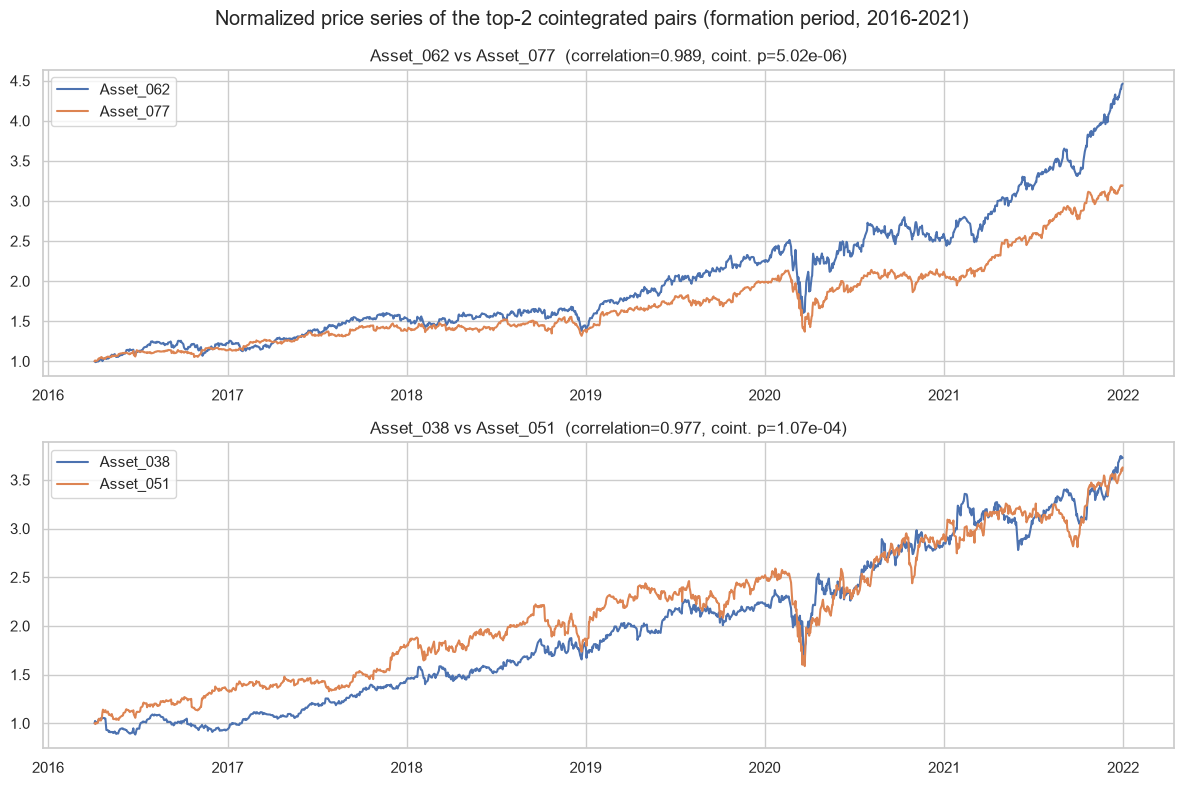

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, (_, row) in zip(axes, selected_pairs.head(2).iterrows()):
    a, b = row["ticker_a"], row["ticker_b"]
    norm_a = formation[a] / formation[a].iloc[0]
    norm_b = formation[b] / formation[b].iloc[0]
    ax.plot(formation.index, norm_a, label=a)
    ax.plot(formation.index, norm_b, label=b)
    ax.set_title(f"{a} vs {b}  (correlation={row['correlation']:.3f}, coint. p={row['coint_pvalue']:.2e})")
    ax.legend()
fig.suptitle("Normalized price series of the top-2 cointegrated pairs (formation period, 2016-2021)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part4_pair_prices_formation.png", dpi=120)
plt.show()


## 3. Out-of-Sample Backtest of Each Selected Pair (2022-2026)

Trading rule (standard textbook defaults, **not** tuned on test data):

- Compute the spread `log(price_a) - hedge_ratio * log(price_b)` using the
  formation-period `hedge_ratio` (frozen).
- Compute a rolling 60-day z-score of the spread (causal -- trailing window
  only).
- **Enter** long-the-spread (long A, short B) when `zscore < -2`; enter
  short-the-spread (short A, long B) when `zscore > +2`.
- **Exit** to flat when `|zscore| < 0.5` (reverted) or `|zscore| > 4`
  (stop-loss).
- Each leg is sized so the two legs sum to one unit of gross exposure, split
  in proportion to the hedge ratio. {TRANSACTION_COST_BPS}bps cost is applied
  to position changes (turnover).


In [4]:
ZSCORE_WINDOW = 60
ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 4.0

pair_results = {}
pair_metrics = {}
for _, row in selected_pairs.iterrows():
    name = f"{row['ticker_a']}/{row['ticker_b']}"
    res = backtest_pair(
        price_pivot, row["ticker_a"], row["ticker_b"], row["hedge_ratio"],
        test_start=TEST_START, zscore_window=ZSCORE_WINDOW,
        entry_z=ENTRY_Z, exit_z=EXIT_Z, stop_z=STOP_Z, cost_bps=TRANSACTION_COST_BPS,
    )
    pair_results[name] = res
    m = compute_performance_metrics(res["net_return"])
    m["pct_time_in_market"] = (res["position"] != 0).mean()
    pair_metrics[name] = m

pair_metrics_df = pd.DataFrame(pair_metrics).T
pair_metrics_df.to_csv(TABLES_DIR / "part4_pair_metrics.csv")
pair_metrics_df[["total_return", "annualized_return", "sharpe_ratio", "max_drawdown", "pct_time_in_market"]]


,total_return,annualized_return,sharpe_ratio,max_drawdown,pct_time_in_market
Asset_062/Asset_077,-0.138735,-0.036437,-0.349276,-0.168943,0.504931
Asset_038/Asset_051,0.396335,0.086508,1.058870,-0.070565,0.344181
Asset_081/Asset_096,0.017101,0.004223,0.092172,-0.182193,0.442801
Asset_092/Asset_093,0.455082,0.097693,0.853270,-0.114142,0.451677
Asset_020/Asset_035,0.078449,0.018947,0.257888,-0.117334,0.512821


Note the irony: **Asset_062/Asset_077**, the single most statistically
significant pair from the formation-period screen (and the only one that
would survive a Bonferroni correction), is among the **worst** performers
out-of-sample. This is a textbook illustration of why pairs selected purely
on an in-sample statistical test must be validated out-of-sample before
being trusted -- a low p-value measures how unlikely the *historical*
co-movement was to arise by chance, not how likely it is to *persist*. The
**aggregated, equal-weight portfolio across all 5 pairs** below is far more
informative than any single pair's result.


## 4. Example: Spread Z-Score and Position Over Time

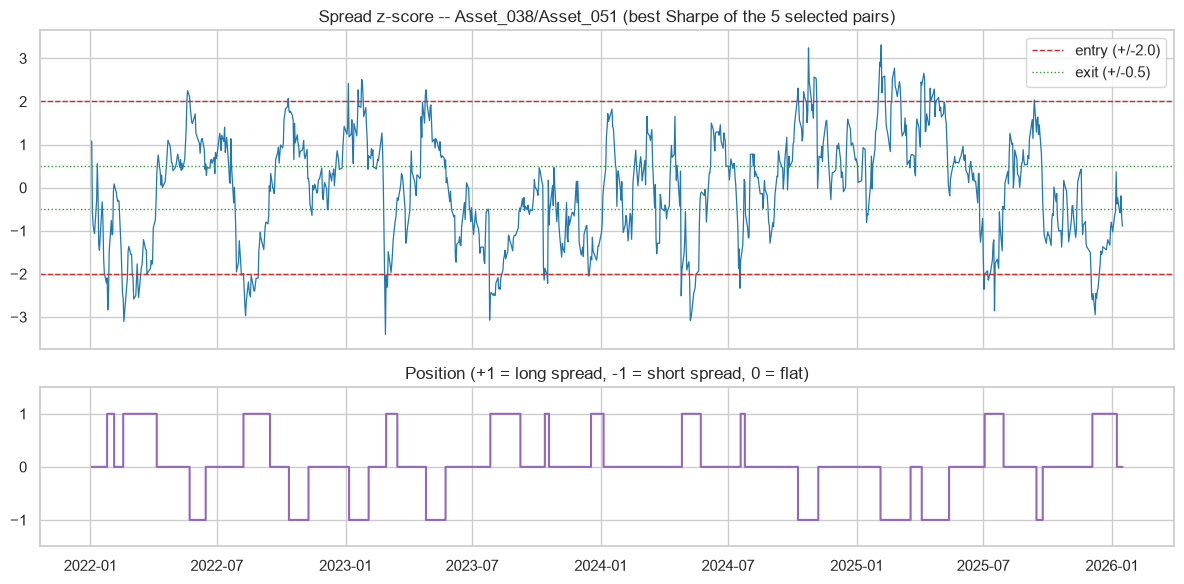

In [5]:
example_name = pair_metrics_df["sharpe_ratio"].idxmax()
example = pair_results[example_name]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(example["date"], example["zscore"], color="tab:blue", linewidth=0.9)
axes[0].axhline(ENTRY_Z, color="tab:red", linestyle="--", linewidth=1, label=f"entry (+/-{ENTRY_Z})")
axes[0].axhline(-ENTRY_Z, color="tab:red", linestyle="--", linewidth=1)
axes[0].axhline(EXIT_Z, color="tab:green", linestyle=":", linewidth=1, label=f"exit (+/-{EXIT_Z})")
axes[0].axhline(-EXIT_Z, color="tab:green", linestyle=":", linewidth=1)
axes[0].set_title(f"Spread z-score -- {example_name} (best Sharpe of the 5 selected pairs)")
axes[0].legend(loc="upper right")

axes[1].plot(example["date"], example["position"], color="tab:purple", drawstyle="steps-post")
axes[1].set_title("Position (+1 = long spread, -1 = short spread, 0 = flat)")
axes[1].set_ylim(-1.5, 1.5)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "part4_example_pair_signal.png", dpi=120)
plt.show()


## 5. Aggregated Stat-Arb Portfolio

In [6]:
stat_arb_portfolio = aggregate_pairs_portfolio(pair_results)
stat_arb_metrics = compute_performance_metrics(stat_arb_portfolio["return"])

benchmark = equal_weight_benchmark(prices, start_date=TEST_START)

metrics_table = pd.DataFrame({
    "Stat-arb portfolio (5 pairs, equal-weight)": stat_arb_metrics,
    "Equal-weight benchmark": compute_performance_metrics(benchmark["return"]),
})
metrics_table.to_csv(TABLES_DIR / "part4_statarb_portfolio_metrics.csv")

display_table = metrics_table.astype(object)
for r in ["total_return", "annualized_return", "annualized_volatility", "max_drawdown", "avg_drawdown", "win_rate"]:
    display_table.loc[r] = display_table.loc[r].apply(lambda x: f"{x * 100:.2f}%")
display_table


,"Stat-arb portfolio (5 pairs, equal-weight)",Equal-weight benchmark
total_return,15.65%,66.08%
annualized_return,3.68%,13.44%
annualized_volatility,4.35%,15.12%
sharpe_ratio,0.853337,0.909499
sortino_ratio,1.288096,1.242664
calmar_ratio,0.818494,0.687731
max_drawdown,-4.50%,-19.54%
avg_drawdown,-1.14%,-4.49%
win_rate,50.49%,53.75%
profit_factor,1.171373,1.176247


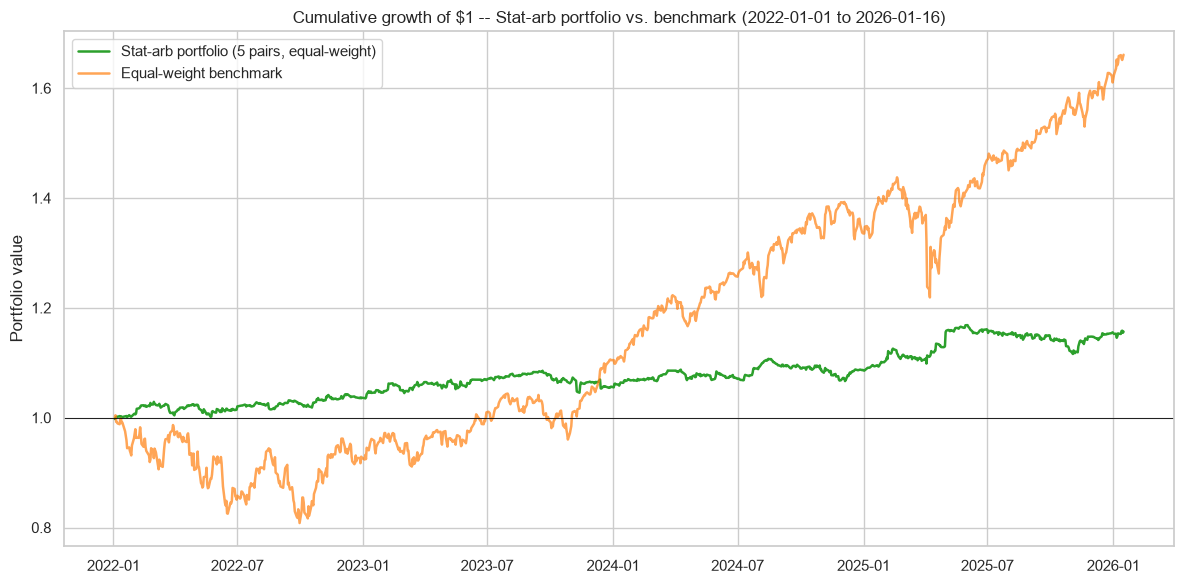

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(stat_arb_portfolio["date"], (1 + stat_arb_portfolio["return"]).cumprod(),
        label="Stat-arb portfolio (5 pairs, equal-weight)", linewidth=1.8, color="tab:green")
ax.plot(benchmark["date"], (1 + benchmark["return"]).cumprod(),
        label="Equal-weight benchmark", linewidth=1.8, color="tab:orange", alpha=0.7)
ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_title(f"Cumulative growth of $1 -- Stat-arb portfolio vs. benchmark "
             f"({TEST_START.date()} to {TEST_END.date()})")
ax.set_ylabel("Portfolio value")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part4_statarb_cumulative.png", dpi=120)
plt.show()


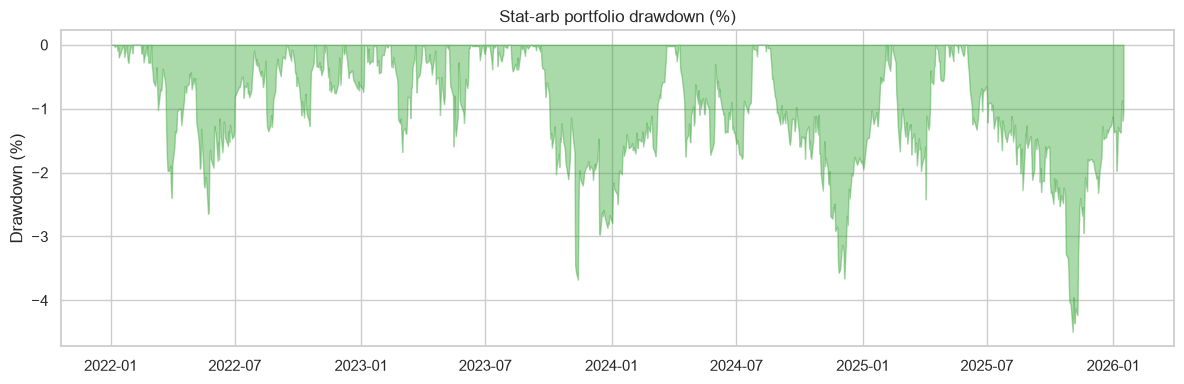

In [8]:
dd_statarb = drawdown_series(stat_arb_portfolio.set_index("date")["return"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dd_statarb.index, dd_statarb.values * 100, 0, color="tab:green", alpha=0.4)
ax.set_title("Stat-arb portfolio drawdown (%)")
ax.set_ylabel("Drawdown (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part4_statarb_drawdown.png", dpi=120)
plt.show()


## 6. Blending with the Part 3 Long/Short Strategy

Recompute Part 3's test-period long/short decile strategy (same
configuration as `src/config.py`: `n_long = n_short`, `rebalance_freq`, and
`cost_bps`) and align it on the same dates as the stat-arb portfolio above,
then look at how the two return streams relate.


In [9]:
oos = pd.read_csv(PROCESSED_DIR / "oos_scores.csv", parse_dates=["date"])
test_scores = oos[(oos["date"] >= TEST_START) & (oos["date"] <= TEST_END)][["date", "ticker", "score"]]

bt = Backtester(n_long=N_LONG, n_short=N_SHORT, rebalance_freq=REBALANCE_FREQ, cost_bps=TRANSACTION_COST_BPS)
main_strategy = bt.run(test_scores, prices, apply_costs=True)[["date", "net_return"]].rename(columns={"net_return": "return"})

combined = main_strategy.merge(stat_arb_portfolio, on="date", suffixes=("_main", "_statarb"), how="inner")
correlation = combined["return_main"].corr(combined["return_statarb"])

print(f"Main strategy:       {len(main_strategy)} days")
print(f"Stat-arb portfolio:  {len(stat_arb_portfolio)} days")
print(f"Overlapping days:    {len(combined)} days")
print(f"\nCorrelation between main strategy and stat-arb overlay daily returns: {correlation:.3f}")


Main strategy:       1013 days
Stat-arb portfolio:  1014 days
Overlapping days:    1013 days

Correlation between main strategy and stat-arb overlay daily returns: 0.105


### The math of blending two return streams

For two return streams `R1` (main strategy) and `R2` (stat-arb overlay)
blended as `R_blend = w * R1 + (1 - w) * R2` (capital split `w` / `1-w`
between the two books):

```
mean(R_blend) = w * mean(R1) + (1 - w) * mean(R2)
var(R_blend)  = w^2 * var(R1) + (1 - w)^2 * var(R2) + 2*w*(1-w) * cov(R1, R2)
cov(R1, R2)   = corr(R1, R2) * std(R1) * std(R2)
```

The lower `corr(R1, R2)`, the smaller the cross term
`2*w*(1-w)*cov(R1,R2)` relative to the individually-weighted variances --
i.e. blended volatility can fall below a simple weighted average of the two
standalone volatilities, for the same blended expected return. This is the
textbook diversification benefit. The sweep below computes the blended
portfolio's metrics across the full range of capital splits `w` and lets the
actual numbers -- not an assumption about which book is "better" -- decide
where the Sharpe-maximizing blend falls.


In [10]:
weights = np.round(np.arange(0.0, 1.01, 0.1), 2)
blend_results = []
for w in weights:
    blended_return = w * combined["return_main"] + (1 - w) * combined["return_statarb"]
    m = compute_performance_metrics(blended_return)
    blend_results.append({
        "w_main": w,
        "annualized_return": m["annualized_return"],
        "annualized_volatility": m["annualized_volatility"],
        "sharpe_ratio": m["sharpe_ratio"],
        "max_drawdown": m["max_drawdown"],
    })

blend_df = pd.DataFrame(blend_results)
blend_df.to_csv(TABLES_DIR / "part4_blend_sweep.csv", index=False)
blend_df


,w_main,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
0,0.0,0.037460,0.043465,0.867848,-0.044965
1,0.1,0.043245,0.049488,0.880231,-0.043275
2,0.2,0.048334,0.066341,0.744655,-0.060429
3,0.3,0.052717,0.088008,0.627688,-0.080782
4,0.4,0.056388,0.111722,0.546730,-0.101960
5,0.5,0.059338,0.136420,0.490558,-0.123365
6,0.6,0.061563,0.161651,0.450118,-0.147266
7,0.7,0.063058,0.187201,0.419883,-0.173654
8,0.8,0.063820,0.212954,0.396530,-0.199939
9,0.9,0.063849,0.238844,0.377999,-0.228146


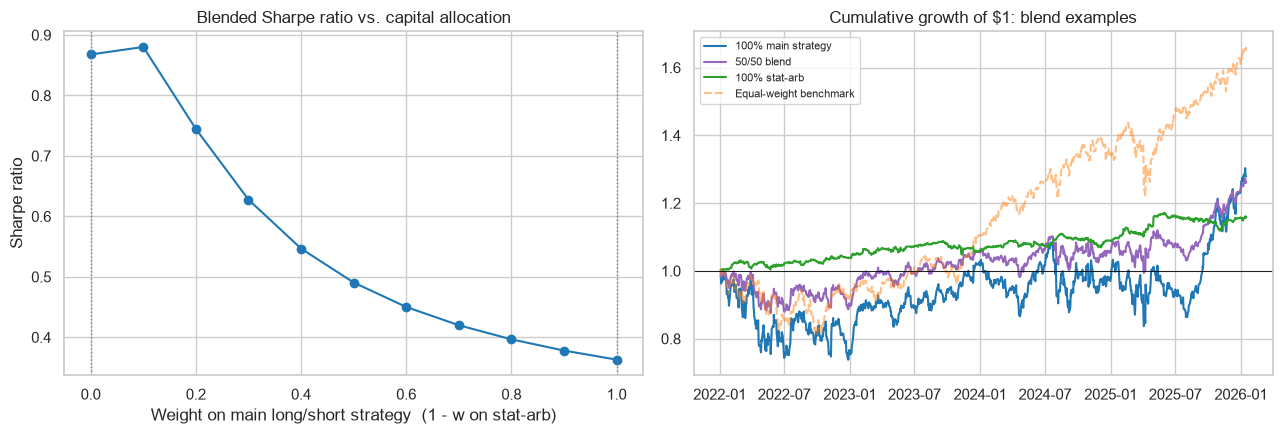

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(blend_df["w_main"], blend_df["sharpe_ratio"], marker="o", color="tab:blue")
axes[0].set_xlabel("Weight on main long/short strategy  (1 - w on stat-arb)")
axes[0].set_ylabel("Sharpe ratio")
axes[0].set_title("Blended Sharpe ratio vs. capital allocation")
axes[0].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].axvline(0.0, color="gray", linestyle=":", linewidth=1)

for w, color, label in [(1.0, "tab:blue", "100% main strategy"),
                        (0.5, "tab:purple", "50/50 blend"),
                        (0.0, "tab:green", "100% stat-arb")]:
    blended_return = w * combined["return_main"] + (1 - w) * combined["return_statarb"]
    axes[1].plot(combined["date"], (1 + blended_return).cumprod(), label=label, color=color)
axes[1].plot(benchmark["date"], (1 + benchmark["return"]).cumprod(),
              label="Equal-weight benchmark", color="tab:orange", alpha=0.5, linestyle="--")
axes[1].axhline(1.0, color="black", linewidth=0.6)
axes[1].set_title("Cumulative growth of $1: blend examples")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "part4_blend_analysis.png", dpi=120)
plt.show()


**Result**: the correlation between the two daily return streams is low
(~0.10). Over this test period, the stat-arb portfolio actually has a
*higher* standalone Sharpe ratio (~0.87) than the main long/short strategy
(~0.36) -- this is not a case of "a low-Sharpe diversifier helping anyway";
the pairs-trading book is the stronger of the two return streams on its own
here. The blended Sharpe is maximized around `w_main ~ 0.1` (~90% stat-arb /
10% main, Sharpe ~0.88), only marginally above 100% stat-arb (~0.87) --
consistent with the low correlation providing a small additional
diversification benefit, while the main strategy's much higher volatility
and lower Sharpe mean it warrants only a small allocation in a
Sharpe-maximizing blend over this particular test period.


## Summary

- **Pair selection** (correlation pre-screen + Engle-Granger cointegration +
  OLS hedge ratio) was performed **only on 2016-2021**; the resulting pairs
  and hedge ratios were frozen and traded **out-of-sample on 2022-2026**
  with a standard, untuned rolling-z-score mean-reversion rule.
- **Individual pair results are mixed** -- including the single
  most-significant (and Bonferroni-surviving) pair underperforming
  out-of-sample -- which is the expected, honest outcome of testing many
  hypotheses and is exactly why pair selection alone is not a strategy.
- **The aggregated, equal-weight 5-pair portfolio** is a meaningfully
  different return stream from both the benchmark and Part 3's long/short
  strategy: low volatility, shallow drawdowns, and (by construction) close
  to market-neutral.
- **Blending**: the correlation between the stat-arb overlay and Part 3's
  long/short strategy is low (~0.10) -- they are genuinely different sources
  of return, not two variations on the same market-direction bet. Over this
  test period the stat-arb book's standalone Sharpe (~0.87) actually exceeds
  the main strategy's (~0.36); the Sharpe-maximizing blend (~90% stat-arb /
  10% main) is only marginally better than pure stat-arb, so the main
  strategy contributes only a small, non-negative share in an
  optimally-blended portfolio over this test period.

## Overall project conclusion

- Part 1 built ~32 causal features (technical + cross-sectional) from raw
  OHLCV data with no look-ahead in any computation.
- Part 2's walk-forward ensemble (Ridge + LightGBM + Logistic, retrained
  annually with an embargo) produced a modest but positive Information
  Coefficient out-of-sample (mean ~0.018, positive in 5 of 7 years).
- Part 3 turned that score into a long/short decile portfolio and found that,
  after transaction costs, its return is mostly explained by unintended
  market-beta exposure rather than a statistically significant alpha.
- Part 4 added a pairs-trading overlay -- selected without any test-period
  information -- whose largely uncorrelated, lower-volatility return stream
  had a considerably higher standalone Sharpe than the Part 3 strategy over
  this test period, with a small allocation to Part 3's strategy on top of
  it providing a marginal further improvement thanks to the low correlation
  between the two.

Every train/validation/test boundary, embargo, and pair-selection step in
this project respects the same rule: **no computation is ever allowed to use
information from a date it is trying to predict or trade.**
